In [1]:
import timm
normal_model = timm.create_model('efficientnet_b2', pretrained=True, num_classes=2)
robust_model = timm.create_model('efficientnet_b2', pretrained=True, num_classes=2)

In [2]:
"""from google.colab import drive
drive.mount('/content/drive')
"""

"from google.colab import drive\ndrive.mount('/content/drive')\n"

# DATASET

In [2]:
import os
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from torch.utils.data import DataLoader
import torch
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm
import torch.nn as nn

class RealFakeDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform

        # Expecting subfolders 'real/' and 'fake/' inside root_dir
        for label_str, label in [("real", 0), ("fake", 1)]:
            folder = Path(root_dir) / label_str
            if not folder.exists():
                continue
            for file in folder.glob("*.png"):
                self.samples.append((file, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label


    def collate_fn(self, batch):
        images, labels = zip(*batch)  # unzip list of tuples
        images = torch.stack(images)  # stack image tensors into a single batch tensor
        labels = torch.tensor(labels) # convert labels to a tensor
        return {"image": images, "label":labels }




# DATALOADER

Color Augmentation might be beneficial against adversarial attacks. <br>
Without ColorJitter() -> 95% accuracy, 2% accuracy FGSM 0.001 epsilon <br>
With ColorJitter() -> 90% accuracy, 6% accyract FGSN 0.001 epsilon

In [3]:
train_path = "./dffd_small/train/"
test_path = "./dffd_small/test/"
validation_path = "./dffd_small/validation/"
unseen_path = "./dffd_small/unseen/"

MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]
train_img_augm = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

test_img_augm = transforms.Compose([
    transforms.Resize((260, 260)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

In [4]:
def denormalize(tensor, mean, std, device="cpu"):

    if isinstance(mean, list):
        mean = torch.tensor(mean).to(device)
    if isinstance(std, list):
        std = torch.tensor(std).to(device)

    return tensor * std.view(1, -1, 1, 1) + mean.view(1, -1, 1, 1)

In [5]:
train_dataset = RealFakeDataset(train_path, transform=train_img_augm)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=train_dataset.collate_fn,num_workers=2)

test_dataset = RealFakeDataset(test_path, test_img_augm)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True, collate_fn=test_dataset.collate_fn,num_workers=2)

validation_dataset = RealFakeDataset(validation_path, transform=test_img_augm)
validation_dataloader = DataLoader(validation_dataset, batch_size=32, shuffle=True, collate_fn=validation_dataset.collate_fn,num_workers=2)

unseen_dataset = RealFakeDataset(unseen_path, transform=test_img_augm)
unseen_dataloader = DataLoader(unseen_dataset, batch_size=32, shuffle=True, collate_fn=unseen_dataset.collate_fn,num_workers=2)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.129035].


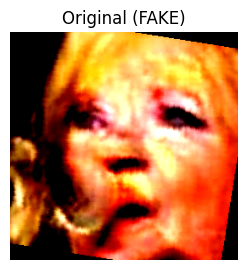

In [6]:
for i, elem in enumerate(train_dataloader):
    if(i==1):
        break
    
    with torch.no_grad():
        orig_img = elem["image"][0]
        orig_img = orig_img.permute(1,2,0).squeeze(0)
        plt.figure(figsize=(10, 3))
        plt.subplot(1, 3, 1)
        target = "FAKE" if elem["label"][0] == 1 else "REAL"
        plt.title(f"Original ({target})")
        plt.imshow(orig_img)
        plt.axis("off")
    

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
loss_ce = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(normal_model.parameters(), 0.0001, weight_decay=0.0001)


# TRAIN

In [7]:
# Freeze all parameters
for param in normal_model.parameters():
    param.requires_grad = False

# Unfreeze selected final layers
for layer_name in ['conv_head', 'bn2', 'global_pool', 'classifier']:
    layer = getattr(normal_model, layer_name)
    for param in layer.parameters():
        param.requires_grad = True


for param in robust_model.parameters():
    param.requires_grad = True

In [9]:
normal_model.to(device)
for epoch in range(1):
    normal_model.train()
    for batch in tqdm(train_dataloader):
        images, labels = batch["image"], batch["label"]
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = normal_model(images)
        loss = loss_ce(outputs, labels)
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch+1}/{1}], Loss: {loss.item():.4f}")

normal_model.to("cpu")

100%|██████████| 250/250 [00:13<00:00, 19.06it/s]

Epoch [1/1], Loss: 0.5651


EfficientNet(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2

In [8]:
def report(model, test_loader, loss):
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
    import matplotlib.pyplot as plt
    model = model.to(device)
    model.eval()
    all_predictions = []
    all_targets = []

    total_loss = 0.0
    with torch.no_grad():
      for batch in tqdm(test_loader):
        input, target = batch["image"], batch["label"]

        input = input.to(device)
        target = target.to(device)

        output = model(input)

        l = loss(output, target)
        total_loss += l.item()

        # Get predictions
        preds = torch.argmax(output, dim=1)  # Adjust if it's binary or multilabel

        all_predictions.extend(preds.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

    # Print classification report
    print("\nClassification Report:")
    print(classification_report(all_targets, all_predictions, digits=4))  # Adjust labels if needed

    # Plot confusion matrix
    label_names = ["REAL", "FAKE"]

    cm = confusion_matrix(all_targets, all_predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.show()

100%|██████████| 63/63 [00:03<00:00, 18.63it/s]


Classification Report:
              precision    recall  f1-score   support

           0     0.4964    0.8320    0.6218      1000
           1     0.4815    0.1560    0.2356      1000

    accuracy                         0.4940      2000
   macro avg     0.4890    0.4940    0.4287      2000
weighted avg     0.4890    0.4940    0.4287      2000



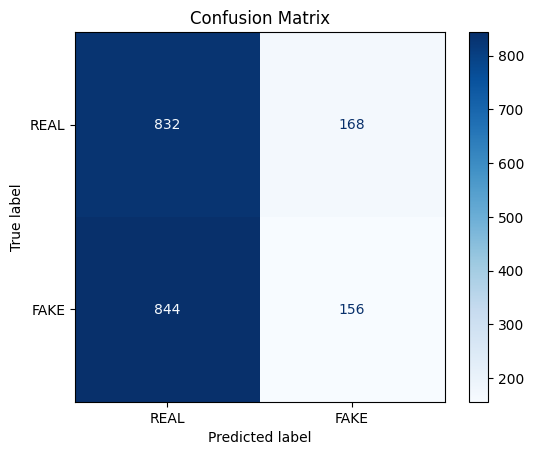

In [9]:
report(normal_model, validation_dataloader, loss_ce)

100%|██████████| 63/63 [00:02<00:00, 23.00it/s]


Classification Report:
              precision    recall  f1-score   support

           0     0.5660    0.7800    0.6560      1000
           1     0.6463    0.4020    0.4957      1000

    accuracy                         0.5910      2000
   macro avg     0.6062    0.5910    0.5758      2000
weighted avg     0.6062    0.5910    0.5758      2000



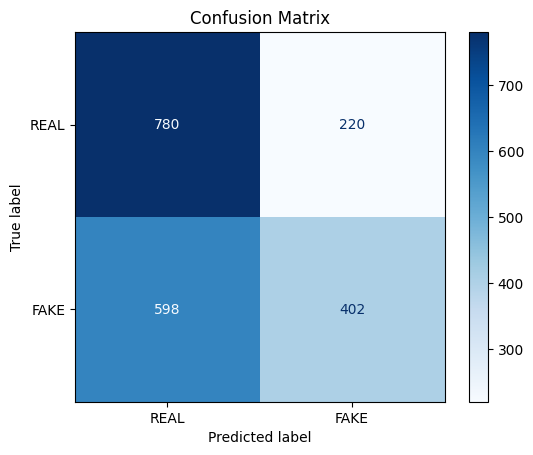

In [12]:
report(normal_model, unseen_dataloader, loss_ce)

# Adversarial Attack

In [ ]:
"""import torch
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# ImageNet normalization stats
imagenet_mean = torch.tensor(MEAN).view(1,3,1,1)
imagenet_std = torch.tensor(STD).view(1,3,1,1)

def fgsm_attack_imagenet_norm(model, images, labels, epsilon):
    
    model.eval()
    
    # Set requires_grad on normalized images
    img = images.clone().detach()
    img.requires_grad = True

    outputs = model(img)
    loss = torch.nn.functional.cross_entropy(outputs, labels)
    model.zero_grad()
    loss.backward()
    
    # Get gradient on normalized images
    grad = img.grad.data
    
    perturbation = epsilon * torch.sign(grad)
    images_perturbed = img + perturbation

    return images_perturbed.detach()

def evaluate_fgsm_imagenet_norm(model, dataloader, device, epsilon=0.01, visualize=False, num_visualize=5):
    model.eval()
    model.to(device)
    correct_clean = 0
    correct_adv = 0

    all_labels = []
    all_preds_clean = []
    all_preds_adv = []

    for batch in tqdm(dataloader):
        images, labels = batch["image"].to(device), batch["label"].to(device)
        
        # Images assumed normalized already (ImageNet norm)
        with torch.no_grad():
            outputs_clean = model(images)
            preds_clean = torch.argmax(outputs_clean, dim=1)
        
        adv_images = fgsm_attack_imagenet_norm(model, images, labels, epsilon)

        with torch.no_grad():
            outputs_adv = model(adv_images)
            preds_adv = torch.argmax(outputs_adv, dim=1)
        
        correct_clean += (preds_clean == labels).sum().item()
        correct_adv += (preds_adv == labels).sum().item()
        
        all_labels.extend(labels.cpu().numpy())
        all_preds_clean.extend(preds_clean.cpu().numpy())
        all_preds_adv.extend(preds_adv.cpu().numpy())
        
        if visualize and num_visualize > 0:
            for i in range(min(num_visualize, images.size(0))):
                plt.figure(figsize=(5,5))

                plt.subplot(1,3,1)
                plt.title(f"Original: {labels[i].item()}")
                # Unnormalize for display
                img = images[i].detach().cpu().permute(1,2,0).numpy()
                img = img.clip(0,1)
                plt.imshow(img)
                plt.axis('off')
                
                plt.subplot(1,3,2)
                plt.title(f"Adv (ε={epsilon})")
                adv_img = adv_images[i].detach().cpu().permute(1,2,0).numpy()
                adv_img = adv_img.clip(0,1)
                plt.imshow(adv_img)
                plt.axis('off')

                plt.subplot(1,3,3)
                plt.title(f"Difference")
                diff = np.clip((adv_img-img)*10, 0, 1)
                plt.imshow(diff)
                plt.axis('off')
                plt.show()
                
                num_visualize -= 1
                if num_visualize == 0:
                    break

    accuracy_clean = 100.0 * correct_clean / len(dataloader.dataset)
    accuracy_adv = 100.0 * correct_adv / len(dataloader.dataset)

    print(f"Clean Accuracy: {accuracy_clean:.2f}%")
    print(f"FGSM Adversarial Accuracy (ε={epsilon}): {accuracy_adv:.2f}%\n")

    print("Classification Report on Clean Data:")
    print(classification_report(all_labels, all_preds_clean, digits=4))

    print("Classification Report on Adversarial Data:")
    print(classification_report(all_labels, all_preds_adv, digits=4))

    print("Confusion Matrix on Adversarial Data:")
    print(confusion_matrix(all_labels, all_preds_adv))

    return accuracy_clean, accuracy_adv
"""

In [10]:
import torch
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import torchvision.transforms as transforms

def fgsm_attack(images, epsilon, grad, mean, std):
    eps_norm = epsilon / torch.tensor(STD).to(device)
    sign_data_grad = grad.sign()
    perturbed = images + eps_norm.view(1, 3, 1, 1) * sign_data_grad.sign()
    return clamp_normed(perturbed, mean, std)

def denorm(batch, mean, std, device):
    if isinstance(mean, list):
        mean = torch.tensor(mean).to(device)
    if isinstance(std, list):
        std = torch.tensor(std).to(device)
    return batch * std.view(1, -1, 1, 1) + mean.view(1, -1, 1, 1)

def pgd_attack(model, images, labels, epsilon, alpha, steps):
    adv_images = images.clone().detach()
    for _ in range(steps):
        adv_images.requires_grad = True
        outputs = model(adv_images)
        loss = F.cross_entropy(outputs, labels)
        grad = torch.autograd.grad(loss, adv_images)[0]
        adv_images = adv_images + alpha * grad.sign()  # Update
        # Project back to ε-ball (no clamping to [0,1] yet)
        delta = adv_images - images
        delta = torch.clamp(delta, -epsilon, epsilon)
        adv_images = (images + delta).detach()
    return adv_images

def normalize_batch(batch):
    transform = transforms.Normalize(mean=MEAN, std=STD)
    return torch.stack([transform(img) for img in batch])

def clamp_normed(tensor, mean, std):
    mean = torch.tensor(mean).view(1, -1, 1, 1).to(tensor.device)
    std = torch.tensor(std).view(1, -1, 1, 1).to(tensor.device)
    # Calculate min and max normalized pixel values corresponding to [0,1] raw
    min_val = (0 - mean) / std
    max_val = (1 - mean) / std
    return torch.max(torch.min(tensor, max_val), min_val)

def evaluate_fgsm(model, dataloader, device, epsilon=0.01, visualize=False, num_visualize=5):
    model.eval()
    model.to(device)

    correct_adv = 0
    total_samples = 0

    all_labels = []
    all_preds_adv = []

    for batch in tqdm(dataloader):
        images, labels = batch["image"].to(device), batch["label"].to(device)
        images.requires_grad = True
        
        model.zero_grad()
        # Forward pass on clean images
        outputs = model(images)
        loss = F.cross_entropy(outputs, labels)
        
        # Zero grad and backward pass
        
        loss.backward()

        # Get gradients
        image_grad = images.grad.data

        # Apply FGSM attack
        #alpha = epsilon/4
        # with steps = 1 should be the same for FGSM
        #adv_images = pgd_attack(model, images, labels, epsilon=epsilon, alpha=alpha, steps=10)

        adv_images = fgsm_attack(images, epsilon, image_grad, MEAN, STD, )

        # Forward pass on adversarial examples
        with torch.no_grad():
            adv_outputs = model(adv_images)
            adv_preds = adv_outputs.argmax(dim=1)

        # Accuracy
        correct_adv += (adv_preds == labels).sum().item()
        total_samples += labels.size(0)

        # Save predictions and labels for reporting
        all_labels.extend(labels.cpu().numpy())
        all_preds_adv.extend(adv_preds.cpu().numpy())

        if visualize and num_visualize > 0:
            adv_visual = denorm(adv_images, MEAN, STD, device).detach()
            images_visual = denorm(images, MEAN, STD, device).detach()
            for i in range(min(num_visualize, images.size(0))):
                plt.figure(figsize=(10, 3))

                orig = images_visual[i].detach().cpu().permute(1, 2, 0).numpy()
                adv = adv_visual[i].detach().cpu().permute(1, 2, 0).numpy()
                diff = np.clip((adv - orig) * 10, 0, 1)

                plt.subplot(1, 3, 1)
                plt.title(f"Original: {labels[i].item()}")
                plt.imshow(orig.clip(0, 1))
                plt.axis('off')

                plt.subplot(1, 3, 2)
                plt.title(f"Adv (ε={epsilon})")
                plt.imshow(adv.clip(0, 1))
                plt.axis('off')

                plt.subplot(1, 3, 3)
                plt.title("Difference")
                plt.imshow(diff)
                plt.axis('off')

                plt.show()

                num_visualize -= 1
                if num_visualize == 0:
                    break

    accuracy_adv = 100.0 * correct_adv / total_samples if total_samples > 0 else 0.0

    print(f"\nClassification Report on Adversarial Data (epsilon = {epsilon}):")
    print(classification_report(all_labels, all_preds_adv, digits=4))

    print("\nConfusion Matrix on Adversarial Data:")
    print(confusion_matrix(all_labels, all_preds_adv))

    return accuracy_adv


In [ ]:
"""import torch
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import torchvision.transforms as transforms


def fgsm_attack(images, epsilon, grad):
    sign_data_grad = grad.sign()
    perturbed_image = images + epsilon * sign_data_grad
    return torch.clamp(perturbed_image, 0, 1)

def denorm(batch, mean, std, device):
    if isinstance(mean, list):
        mean = torch.tensor(mean).to(device)
    if isinstance(std, list):
        std = torch.tensor(std).to(device)
    return batch * std.view(1, -1, 1, 1) + mean.view(1, -1, 1, 1)

def normalize_batch(batch):
    transform = transforms.Normalize(mean=MEAN, std=STD)
    return torch.stack([transform(img) for img in batch])

def evaluate_fgsm(model, dataloader, device, epsilon=0.01, visualize=False, num_visualize=5):
    model.eval()
    model.to(device)

    correct_adv = 0
    total_samples = 0

    all_labels = []
    all_preds_adv = []

    for batch in tqdm(dataloader):
        images, labels = batch["image"].to(device), batch["label"].to(device)
        images.requires_grad = True

        # Forward pass on clean images
        outputs = model(images)
        loss = F.cross_entropy(outputs, labels)
        
        # Zero grad and backward pass
        model.zero_grad()
        loss.backward()

        # Get gradients
        image_grad = images.grad.data

        # Denormalize before perturbation
        images_denorm = denorm(images, MEAN, STD, device)

        # Apply FGSM attack
        adv_images = fgsm_attack(images_denorm, epsilon, image_grad)

        # Re-normalize after attack
        adv_images_norm = normalize_batch(adv_images).to(device)

        # Forward pass on adversarial examples
        with torch.no_grad():
            adv_outputs = model(adv_images_norm)
            adv_preds = adv_outputs.argmax(dim=1)

        # Accuracy
        correct_adv += (adv_preds == labels).sum().item()
        total_samples += labels.size(0)

        # Save predictions and labels for reporting
        all_labels.extend(labels.cpu().numpy())
        all_preds_adv.extend(adv_preds.cpu().numpy())

        # Visualization
        if visualize and num_visualize > 0:
            for i in range(min(num_visualize, images.size(0))):
                plt.figure(figsize=(10, 3))

                orig = images_denorm[i].detach().cpu().permute(1, 2, 0).numpy()
                adv = adv_images[i].detach().cpu().permute(1, 2, 0).numpy()
                diff = np.clip((adv - orig) * 10, 0, 1)

                plt.subplot(1, 3, 1)
                plt.title(f"Original: {labels[i].item()}")
                plt.imshow(orig.clip(0, 1))
                plt.axis('off')

                plt.subplot(1, 3, 2)
                plt.title(f"Adv (ε={epsilon})")
                plt.imshow(adv.clip(0, 1))
                plt.axis('off')

                plt.subplot(1, 3, 3)
                plt.title("Difference")
                plt.imshow(diff)
                plt.axis('off')

                plt.show()

                num_visualize -= 1
                if num_visualize == 0:
                    break

    accuracy_adv = 100.0 * correct_adv / total_samples if total_samples > 0 else 0.0

    print(f"\nClassification Report on Adversarial Data (epsilon = {epsilon}):")
    print(classification_report(all_labels, all_preds_adv, digits=4))

    print("\nConfusion Matrix on Adversarial Data:")
    print(confusion_matrix(all_labels, all_preds_adv))

    return accuracy_adv
"""

  0%|          | 0/63 [00:00<?, ?it/s]

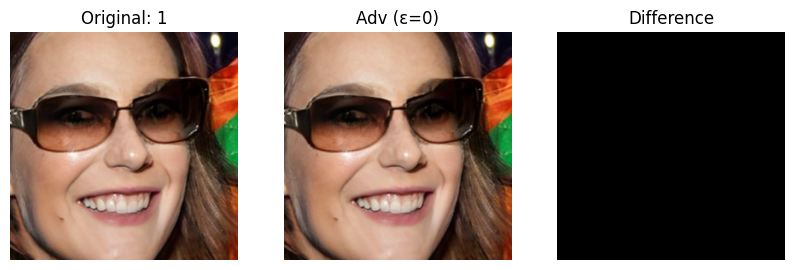

100%|██████████| 63/63 [00:08<00:00,  7.69it/s]



Classification Report on Adversarial Data (epsilon = 0):
              precision    recall  f1-score   support

           0     0.8352    0.8160    0.8255      1000
           1     0.8201    0.8390    0.8295      1000

    accuracy                         0.8275      2000
   macro avg     0.8277    0.8275    0.8275      2000
weighted avg     0.8277    0.8275    0.8275      2000


Confusion Matrix on Adversarial Data:
[[816 184]
 [161 839]]


  0%|          | 0/63 [00:00<?, ?it/s]

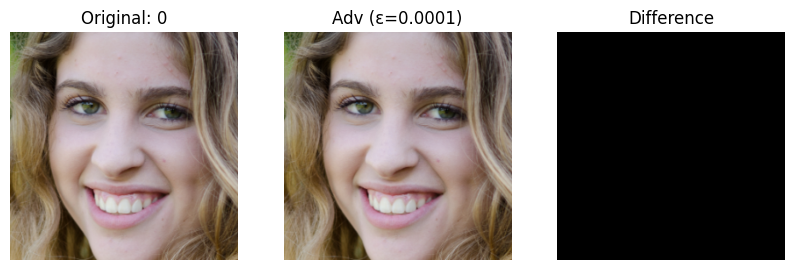

100%|██████████| 63/63 [00:07<00:00,  7.94it/s]



Classification Report on Adversarial Data (epsilon = 0.0001):
              precision    recall  f1-score   support

           0     0.4871    0.3950    0.4362      1000
           1     0.4912    0.5840    0.5336      1000

    accuracy                         0.4895      2000
   macro avg     0.4891    0.4895    0.4849      2000
weighted avg     0.4891    0.4895    0.4849      2000


Confusion Matrix on Adversarial Data:
[[395 605]
 [416 584]]


  0%|          | 0/63 [00:00<?, ?it/s]

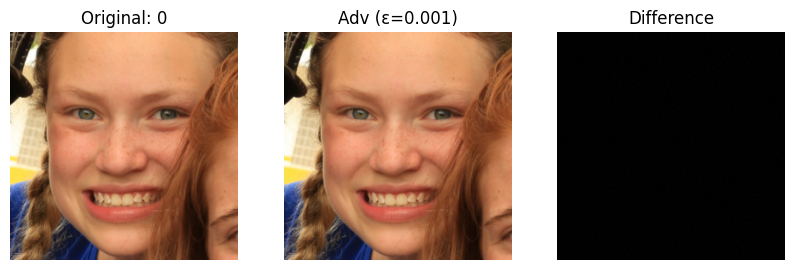

100%|██████████| 63/63 [00:07<00:00,  7.95it/s]



Classification Report on Adversarial Data (epsilon = 0.001):
              precision    recall  f1-score   support

           0     0.0052    0.0050    0.0051      1000
           1     0.0396    0.0410    0.0403      1000

    accuracy                         0.0230      2000
   macro avg     0.0224    0.0230    0.0227      2000
weighted avg     0.0224    0.0230    0.0227      2000


Confusion Matrix on Adversarial Data:
[[  5 995]
 [959  41]]


  0%|          | 0/63 [00:00<?, ?it/s]

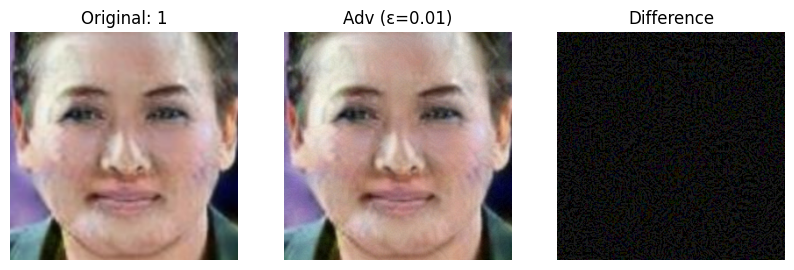

100%|██████████| 63/63 [00:08<00:00,  7.75it/s]



Classification Report on Adversarial Data (epsilon = 0.01):
              precision    recall  f1-score   support

           0     0.0314    0.0320    0.0317      1000
           1     0.0133    0.0130    0.0131      1000

    accuracy                         0.0225      2000
   macro avg     0.0223    0.0225    0.0224      2000
weighted avg     0.0223    0.0225    0.0224      2000


Confusion Matrix on Adversarial Data:
[[ 32 968]
 [987  13]]


  0%|          | 0/63 [00:00<?, ?it/s]

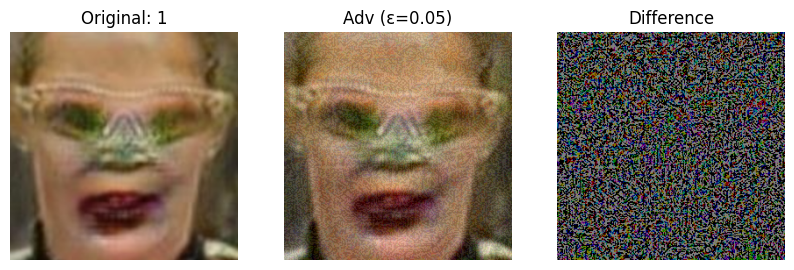

100%|██████████| 63/63 [00:08<00:00,  7.85it/s]



Classification Report on Adversarial Data (epsilon = 0.05):
              precision    recall  f1-score   support

           0     0.5066    0.9240    0.6544      1000
           1     0.5682    0.1000    0.1701      1000

    accuracy                         0.5120      2000
   macro avg     0.5374    0.5120    0.4122      2000
weighted avg     0.5374    0.5120    0.4122      2000


Confusion Matrix on Adversarial Data:
[[924  76]
 [900 100]]


  0%|          | 0/63 [00:00<?, ?it/s]

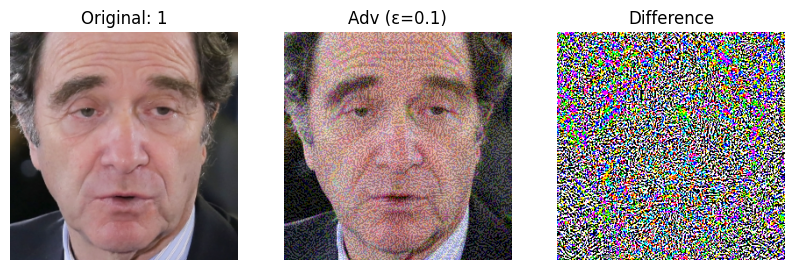

100%|██████████| 63/63 [00:08<00:00,  7.70it/s]


Classification Report on Adversarial Data (epsilon = 0.1):
              precision    recall  f1-score   support

           0     0.5182    0.5700    0.5429      1000
           1     0.5222    0.4700    0.4947      1000

    accuracy                         0.5200      2000
   macro avg     0.5202    0.5200    0.5188      2000
weighted avg     0.5202    0.5200    0.5188      2000


Confusion Matrix on Adversarial Data:
[[570 430]
 [530 470]]


In [15]:
epsilons = [0, 0.0001, 0.001, 0.01, .05, .1]
accuracies = []

# Run test for each epsilon
for eps in epsilons:
    acc = evaluate_fgsm(normal_model,test_dataloader, device, eps, visualize=True, num_visualize=1)
    accuracies.append(acc)

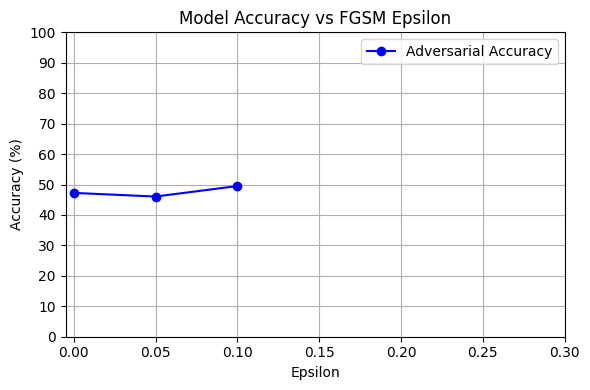

In [98]:
plt.figure(figsize=(6, 4))
plt.plot(epsilons, accuracies, marker='o', linestyle='-', color='blue', label='Adversarial Accuracy')

plt.xticks(np.arange(0, 0.35, step=0.05))
plt.yticks(np.arange(0, 110, step=10))

plt.title("Model Accuracy vs FGSM Epsilon")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Adversarial Training
The model receives a huge downgrade in performances when FGSM is used. <br>
We can try to train the model using that perturbed images

Regularization implementation (from paper)

In [11]:
class ShallowModel(nn.Module):

    def __init__(self, model):
        super().__init__()
        self.shallow1 = model.conv_stem
        self.shallow2 = model.bn1
        self.shallow3 = model.blocks[0]
        self.shallow4 = model.blocks[1]
        self.shallow5 = model.blocks[2]
    
    def forward(self, x):
        x = self.shallow1(x)
        x = self.shallow2(x)
        
        x = self.shallow3(x)

        x = self.shallow4(x)

        x = self.shallow5(x)

        return x


In [12]:
class DeepModel(nn.Module):
    def __init__(self, model):
        super().__init__()

        self.blocks = model.blocks[3:]
        self.conv_head = model.conv_head
        self.bn2 = model.bn2
        self.global_pool = model.global_pool
        self.classifier = model.classifier

    def forward(self, input):

        x = self.blocks(input)
        x = self.conv_head(x)
        x = self.bn2(x)
        x = self.global_pool(x)
        x = self.classifier(x)

        return x 

In [13]:
class EfficientNet(nn.Module):

    def __init__(self, model):
        super().__init__()

        self.shallow = ShallowModel(model)
        self.deep = DeepModel(model)

    def forward(self, input):

        x = self.shallow(input)
        x = self.deep(x)

        return x

In [14]:
from gc import collect
torch.cuda.empty_cache()
collect()

4462

In [15]:
from sklearn.metrics import f1_score

def evaluate_model(model, test_dataloader, criterion, device):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0.0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in test_dataloader:
            images, labels = batch["image"].to(device), batch["label"].to(device)
            logits = model.deep(model.shallow(images))  # adjust if not split
            loss = criterion(logits, labels)
            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    accuracy = 100.0 * correct / total
    avg_loss = total_loss / len(test_dataloader)
    f1 = f1_score(all_labels, all_preds, average="macro")  # or "weighted" or "micro" depending on your use case

    return avg_loss, accuracy, f1

def calculate_deltas(grad_mean, grad_sigma, r):

    grad_mean_norm = torch.sqrt((grad_mean ** 2).sum(dim=1, keepdim=True)) + 1e-8
    grad_std_norm = torch.sqrt((grad_sigma ** 2).sum(dim=1, keepdim=True)) + 1e-8

    dmu = r*grad_mean/grad_mean_norm
    dsigma = r*grad_sigma/grad_std_norm 

    return dmu, dsigma 

def calculate_f_prime(features, mu, sigma, dmu, dsigma):

        f_norm = (features - mu) / (sigma+1e-8)

        f_prime = f_norm*(sigma+dsigma) + (mu+dmu)

        return f_prime

# Training loop with PMI
def train_with_pmi(model, train_dataloader, eval_loader, optimizer, loss_ce, device, num_epochs=5, alpha=0.1, r=0.1, patience = 3):
    model.to(device)

    best_f1 = 0.0
    counter = 0
    best_model = None
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        
        for batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            images, labels = batch["image"].to(device), batch["label"].to(device)
        
            
            optimizer.zero_grad()
            # First forward step 
            shallow = model.shallow
            shallow_layers = [shallow.shallow1, shallow.shallow2, shallow.shallow3, shallow.shallow4, shallow.shallow5]
        
            dmus = [0 for i in range(len(shallow_layers))]
            dsigmas = [0 for i in range(len(shallow_layers))]

            means = [0 for i in range(len(shallow_layers))]
            stds = [0 for i in range(len(shallow_layers))]
            
            f_primes = [0 for i in range(len(shallow_layers))]
            

            for i, layer in enumerate(shallow_layers):
                if i == 0:
                    # normal forward for first shallow layer on input images
                    feature = layer(images)
                else:
                    # feed perturbed feature from previous layer for subsequent shallow layers
                    feature = layer(f_primes[i-1])
                
                # Calculate Means and Stds
                means[i] = torch.mean(feature, [2,3], keepdim=True)
                means[i].retain_grad()

                stds[i] = torch.std(feature, [2,3], keepdim=True)
                stds[i].retain_grad()

                f_primes[i] = calculate_f_prime(feature, means[i], stds[i], dmus[i], dsigmas[i])
                feature.retain_grad()

            deep = model.deep
            deep_features = deep(f_primes[-1])

            logits = deep_features
            loss = loss_ce(logits, labels)
            
            loss.backward(retain_graph=True)

            # At this point we should have access to gradient wrt mu and sigma 
            for i in range(len(shallow_layers)):
                dmu, dsigma = calculate_deltas(means[i].grad, stds[i].grad, r)
                dmus[i] = dmu.detach_()
                dsigmas[i] = dsigma.detach_()

            for i, layer in enumerate(shallow_layers):
                f_primes[i] = calculate_f_prime(f_primes[i].detach(), means[i], stds[i], dmus[i], dsigmas[i])

            
            logits_perturbed = deep(f_primes[-1])
            
            # Losses 
            loss_perturbed = loss_ce(logits_perturbed, labels)
            loss_clean = loss
            
            total_loss = (1 - alpha) * loss_clean + alpha * loss_perturbed
            
            
            total_loss.backward()
            optimizer.step()
            
            epoch_loss += total_loss.item()
            del loss, loss_clean, loss_perturbed, logits, logits_perturbed

        avg_loss = epoch_loss / len(train_dataloader)
        test_loss, test_acc ,test_f1 = evaluate_model(model, eval_loader, loss_ce, device)
        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f} - Test Loss: {test_loss:.4f} - Accuracy: {test_acc:.2f}%, F1-Score: {test_f1:.4f}")

        
        if(test_f1 > best_f1):
            best_f1 = test_f1
            best_model = model.state_dict()
            counter = 0
        else: 
            counter+=1
            if(counter>=patience):
                print("Early stopping triggered")
                break
    
    return model.load_state_dict(best_model)

In [41]:
import gc
torch.cuda.empty_cache()
#del normal_model
#del eff_model
gc.collect()

0

In [17]:
eff_model = EfficientNet(robust_model)

# Example: Only unfreeze shallow layers
for param in eff_model.shallow.parameters():
    param.requires_grad = True

# Freeze deeper layers if desired
for param in eff_model.deep.parameters():
    param.requires_grad = False


loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(eff_model.parameters(), lr=1e-4, weight_decay=1e-4)
device = "cuda" if torch.cuda.is_available() else "cpu" 
alpha = 0.8
trained_model = train_with_pmi(eff_model, 
                               train_dataloader, 
                               unseen_dataloader, 
                               optimizer, 
                               loss, 
                               device, 
                               num_epochs=7, 
                               alpha=alpha, 
                               r=0.1,
                               patience=3)

Epoch 1/7: 100%|██████████| 250/250 [01:03<00:00,  3.93it/s]


Epoch 1/7 - Loss: 0.7287 - Test Loss: 4.2541 - Accuracy: 42.40%, F1-Score: 0.3250


Epoch 2/7:  11%|█         | 27/250 [00:07<01:00,  3.67it/s]


KeyboardInterrupt: 

# Adversarial Training

100%|██████████| 63/63 [00:03<00:00, 20.19it/s]


Classification Report:
              precision    recall  f1-score   support

           0     0.4783    0.9140    0.6280      1000
           1     0.0337    0.0030    0.0055      1000

    accuracy                         0.4585      2000
   macro avg     0.2560    0.4585    0.3167      2000
weighted avg     0.2560    0.4585    0.3167      2000



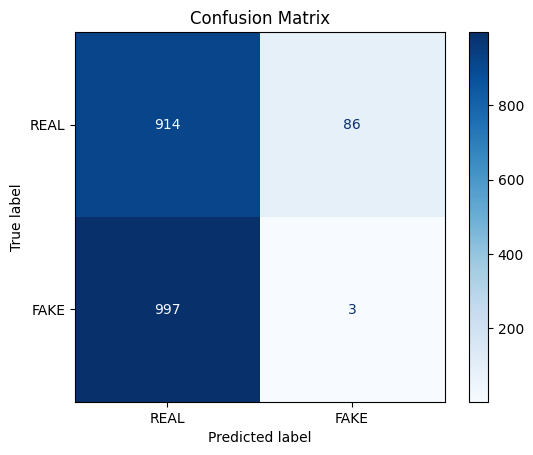

In [33]:
report(eff_model, unseen_dataloader, loss_ce)